In [7]:
import pandas as pd
import baseline_simulator
from utils import *

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1. Print out objectives for all locations on the grid.
2. Try to change the DCM
3. Fix regular price, only optimize scheduled
4. Change utility function to only care about the minimum
5. Should we multiply by max power rate to convert z_sch to hourly price?

In [21]:
tou = np.ones((96,)) * 17.5  # off-peak cents/kWh
tou[64:84] = 36.7  # 4 pm - 9 pm peak
tou[36:56] = 14.9  # 9 am - 2 pm super off-peak
TOU = np.concatenate([tou, tou, tou]) # wrap around for multi-day sessions

In [18]:
sessions_df = pd.read_csv("/Users/sam/Desktop/StationLevelPowerForecasting/data/Sessions3.csv")
sessions_df = sessions_df.sort_values(by='startChargeTime')

test_df = sessions_df[(pd.to_datetime(sessions_df['connectTime']).dt.year == 2024) & (pd.to_datetime(sessions_df['connectTime']).dt.month == 1)]
test_df = test_df[test_df['DurationHrs'] > 0.5]
test_df = test_df[test_df['cumEnergy_Wh'] > 0]
test_df['choice'] = 'SCHEDULED'
sim = baseline_simulator.BaselineSimulator(test_df, verbose=True, flexibility_constant=0.5)

---------------------------------------------------------------------
Done with optimization at 2024-01-02 10:11:14
Optimal prices (per kW): (30, 40)
Optimal prices (per hour): (96.05714285714285, 264.0)
Probabilities [0.48691265 0.20330041 0.30978693]
Utilities [ 0.6072 -0.2662  0.155 ]
Optimized delivery of 16.81 kW to session #6671
Number of active sessions: 1
Current peak options 3.2 6.6
Running DC options 3.2 6.6
Peak thus far 3.2
Profit options [1359.97277035] [2885.84999831] [0.]
new_sch_obj -241.40817856774845
new_reg_obj -414.15000000000003
existing_sch_obj 0.0
existing_reg_obj 0
Profit 1248.8824460252322


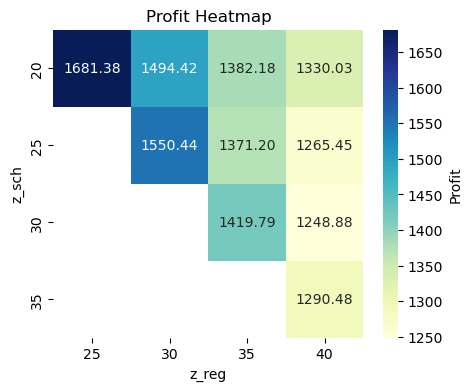

---------------------------------------------------------------------
Done with optimization at 2024-01-03 00:58:06
Optimal prices (per kW): (20, 40)
Optimal prices (per hour): (61.333333333333336, 264.0)
Probabilities [0.70527156 0.08742514 0.2073033 ]
Utilities [ 1.2144 -0.8734 -0.01  ]
Optimized delivery of 9.2 kW to session #6674
Number of active sessions: 1
Current peak options 3.07 6.6
Running DC options 3.2 6.6
Peak thus far 3.2
Profit options [-22.9950008] [1512.99405004] [0.]
new_sch_obj -22.995000000001543
new_reg_obj -185.625
existing_sch_obj 0.0
existing_reg_obj 0
Profit 116.05600136709673


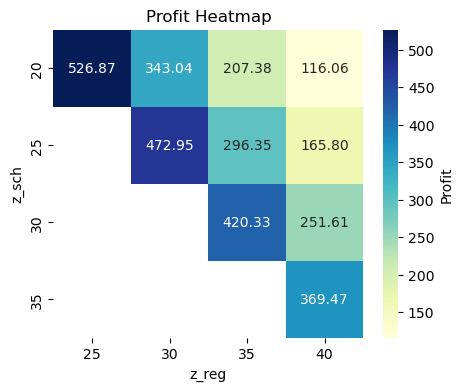

---------------------------------------------------------------------
Done with optimization at 2024-01-03 07:32:04
Optimal prices (per kW): (25, 40)
Optimal prices (per hour): (76.91666666666667, 264.0)
Probabilities [0.60242916 0.13705333 0.26051751]
Utilities [ 0.9108 -0.5698  0.0725]
Optimized delivery of 27.69 kW to session #6675
Number of active sessions: 1
Current peak options 3.2 6.6
Running DC options 3.2 6.6
Peak thus far 3.2
Profit options [-224.93358941] [1057.42905098] [0.]
new_sch_obj -224.93358926893808
new_reg_obj -641.1899999999999
existing_sch_obj 0.0
existing_reg_obj 0
Profit 9.417613812121118


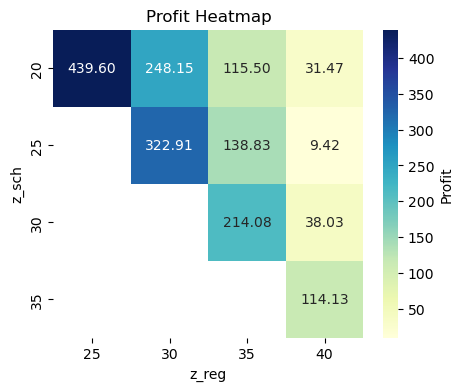

---------------------------------------------------------------------
Done with optimization at 2024-01-03 07:42:17
Optimal prices (per kW): (35, 40)
Optimal prices (per hour): (227.02702702702703, 264.0)
Probabilities [0.37005197 0.28356559 0.34638243]
Utilities [0.3036 0.0374 0.2375]
Optimized delivery of 60.0 kW to session #6676
Number of active sessions: 2
Current peak options 9.47 9.59
Running DC options 9.47 9.59
Peak thus far 9.47
Profit options [1927.59871671] [1667.91538411] [-197.51641801]
new_sch_obj -1009.2433330541869
new_reg_obj -1327.2599999999998
existing_sch_obj -197.51641800813223
existing_reg_obj 0
Profit 1117.8589062196338


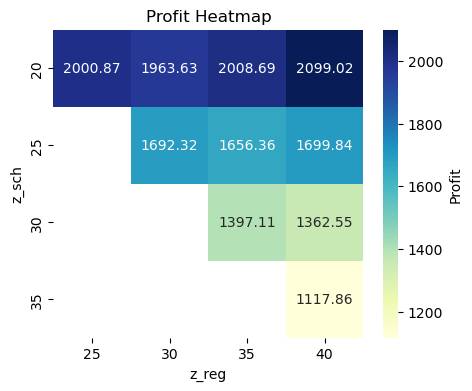

---------------------------------------------------------------------
Done with optimization at 2024-01-03 09:20:31
Optimal prices (per kW): (20, 40)
Optimal prices (per hour): (66.34666666666666, 264.0)
Probabilities [0.70527156 0.08742514 0.2073033 ]
Utilities [ 1.2144 -0.8734 -0.01  ]
Optimized delivery of 12.44 kW to session #6677
Number of active sessions: 3
Current peak options 10.97 17.57
Running DC options 10.97 17.57
Peak thus far 10.97
Profit options [-205.68032796] [2867.87652225] [-892.30956609]
new_sch_obj -63.46185000000003
new_reg_obj -289.905
existing_sch_obj -892.3095660946547
existing_reg_obj 0
Profit -79.31468468739968


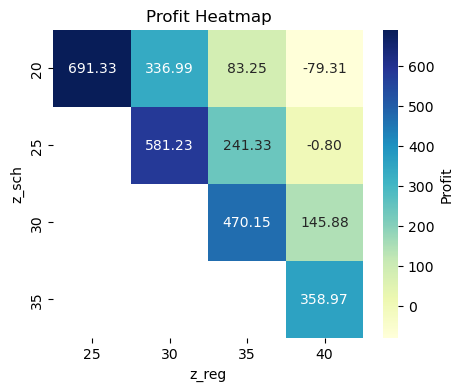

---------------------------------------------------------------------
Done with optimization at 2024-01-03 15:58:16
Optimal prices (per kW): (20, 40)
Optimal prices (per hour): (64.8, 264.0)
Probabilities [0.70527156 0.08742514 0.2073033 ]
Utilities [ 1.2144 -0.8734 -0.01  ]
Optimized delivery of 4.05 kW to session #6678
Number of active sessions: 3
Current peak options 11.91 17.07
Running DC options 11.91 17.07
Peak thus far 11.91
Profit options [582.70858829] [3086.3251769] [47.24556785]
new_sch_obj 67.6934499999382
new_reg_obj -10.88999999999999
existing_sch_obj 47.245567846864034
existing_reg_obj 0
Profit 690.5843778080922


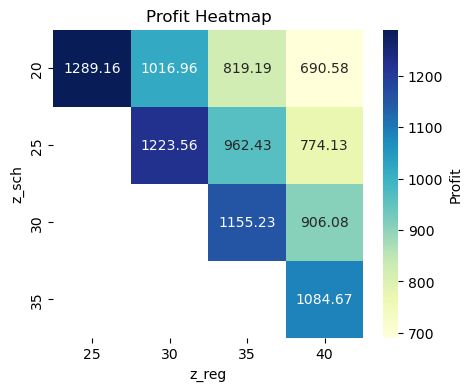

---------------------------------------------------------------------
Done with optimization at 2024-01-04 08:35:54
Optimal prices (per kW): (35, 40)
Optimal prices (per hour): (91.41621621621621, 264.0)
Probabilities [0.37005197 0.28356559 0.34638243]
Utilities [0.3036 0.0374 0.2375]
Optimized delivery of 24.16 kW to session #6680
Number of active sessions: 1
Current peak options 4.83 6.6
Running DC options 11.91 11.91
Peak thus far 11.91
Profit options [-485.63610062] [-575.52000065] [0.]
new_sch_obj -485.6360998760899
new_reg_obj -575.52
existing_sch_obj 0.0
existing_reg_obj 0
Profit -342.90826757782884


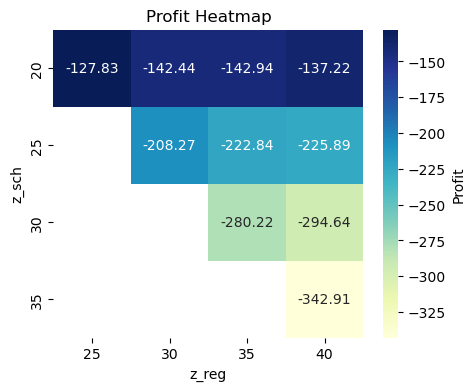

---------------------------------------------------------------------
Done with optimization at 2024-01-04 10:01:10
Optimal prices (per kW): (35, 40)
Optimal prices (per hour): (33.169230769230765, 263.99999999999994)
Probabilities [0.37005197 0.28356559 0.34638243]
Utilities [0.3036 0.0374 0.2375]
Optimized delivery of 3.08 kW to session #6681
Number of active sessions: 2
Current peak options 5.46 11.12
Running DC options 11.91 11.91
Peak thus far 11.91
Profit options [-401.86332254] [-381.36027278] [-339.94527001]
new_sch_obj -61.91804999999762
new_reg_obj -41.415
existing_sch_obj -339.94527001113624
existing_reg_obj 0
Profit -374.6020373500432


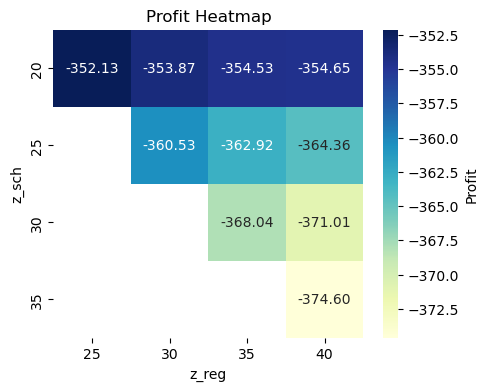

---------------------------------------------------------------------
Done with optimization at 2024-01-04 10:04:15
Optimal prices (per kW): (35, 40)
Optimal prices (per hour): (146.29999999999998, 264.0)
Probabilities [0.37005197 0.28356559 0.34638243]
Utilities [0.3036 0.0374 0.2375]
Optimized delivery of 2.09 kW to session #6679
Number of active sessions: 3
Current peak options 9.47 11.89
Running DC options 11.91 11.91
Peak thus far 11.91
Profit options [-440.77866575] [-440.14446582] [-398.7294649]
new_sch_obj -42.04919999999984
new_reg_obj -41.415
existing_sch_obj -398.72946490182886
existing_reg_obj 0
Profit -426.03372394573194


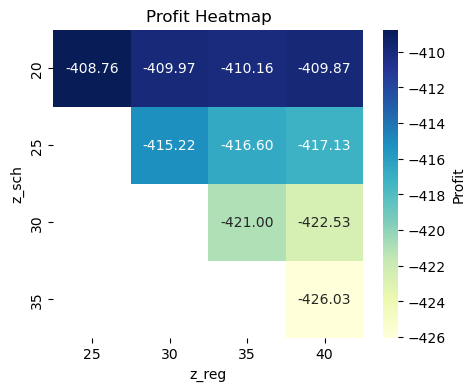

---------------------------------------------------------------------
Done with optimization at 2024-01-04 12:46:43
Optimal prices (per kW): (35, 40)
Optimal prices (per hour): (226.72, 264.0)
Probabilities [0.37005197 0.28356559 0.34638243]
Utilities [0.3036 0.0374 0.2375]
Optimized delivery of 56.68 kW to session #6683
Number of active sessions: 3
Current peak options 11.91 11.91
Running DC options 11.91 11.91
Peak thus far 11.91
Profit options [-503.11788682] [-752.92388683] [-107.11388676]
new_sch_obj -396.0039999865638
new_reg_obj -645.8099999999998
existing_sch_obj -107.1138867644908
existing_reg_obj 0
Profit -436.78544400300234


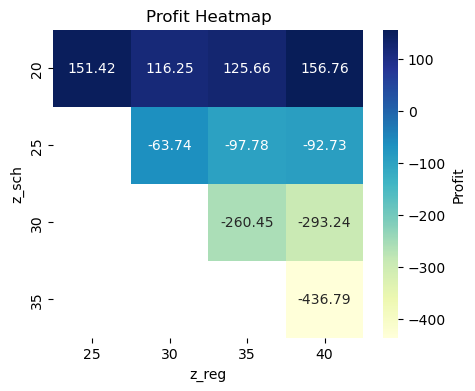

---------------------------------------------------------------------
Done with optimization at 2024-01-04 13:04:29
Optimal prices (per kW): (25, 40)
Optimal prices (per hour): (80.3125, 264.0)
Probabilities [0.60242916 0.13705333 0.26051751]
Utilities [ 0.9108 -0.5698  0.0725]
Optimized delivery of 12.85 kW to session #6684
Number of active sessions: 4
Current peak options 11.91 13.47
Running DC options 11.91 13.47
Peak thus far 11.91
Profit options [-479.77915979] [134.92492495] [-373.61115594]
new_sch_obj -106.16800377313929
new_reg_obj -272.745
existing_sch_obj -373.6111559403742
existing_reg_obj 0
Profit -367.8732966636753


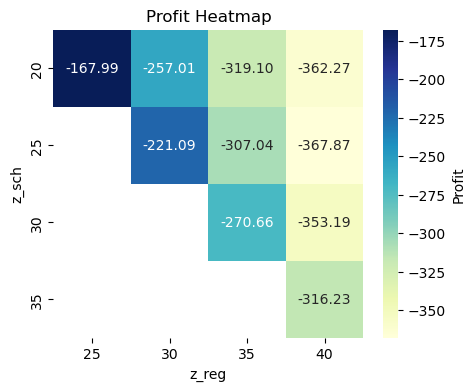

---------------------------------------------------------------------
Done with optimization at 2024-01-04 20:39:00
Optimal prices (per kW): (25, 40)
Optimal prices (per hour): (106.61538461538461, 264.0)
Probabilities [0.60242916 0.13705333 0.26051751]
Utilities [ 0.9108 -0.5698  0.0725]
Optimized delivery of 13.86 kW to session #6685
Number of active sessions: 2
Current peak options 8.11 13.2
Running DC options 11.91 13.2
Peak thus far 11.91
Profit options [-187.7700001] [297.25992457] [-83.82]
new_sch_obj -103.95000000098068
new_reg_obj -265.32
existing_sch_obj -83.81999999959501
existing_reg_obj 0
Profit -94.21424063166522


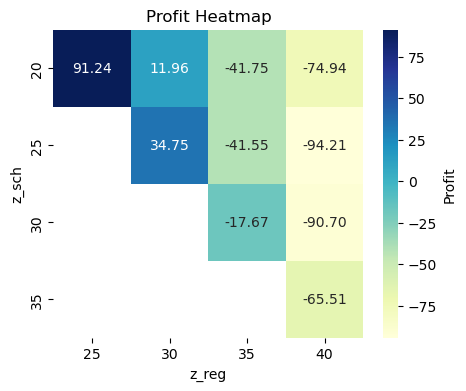

---------------------------------------------------------------------
Done with optimization at 2024-01-05 07:28:07
Optimal prices (per kW): (35, 40)
Optimal prices (per hour): (85.785, 264.0)
Probabilities [0.37005197 0.28356559 0.34638243]
Utilities [0.3036 0.0374 0.2375]
Optimized delivery of 24.51 kW to session #6686
Number of active sessions: 1
Current peak options 4.9 6.6
Running DC options 11.91 11.91
Peak thus far 11.91
Profit options [-492.61080024] [-554.07000026] [0.]
new_sch_obj -492.61079992702946
new_reg_obj -554.07
existing_sch_obj 0.0
existing_reg_obj 0
Profit -339.406786859064


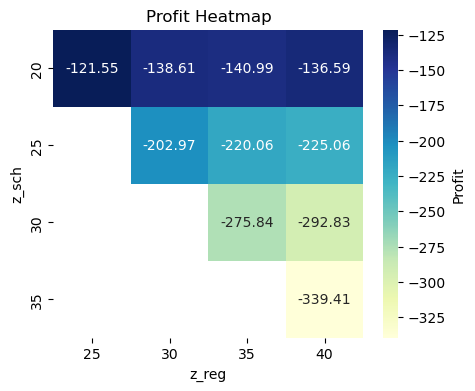

KeyboardInterrupt: 

In [19]:
COST_DC = 2000

power_profiles, prices, hourly_prices = sim.simulate()

In [22]:
DELTA_T = 0.25

agg_power_profile_all_sch = aggregate_power_profiles(test_df, power_profiles, DELTA_T)
profit_all_sch = get_profit(test_df, power_profiles, prices, DELTA_T, TOU)
profit_all_sch - COST_DC * max(agg_power_profile_all_sch), max(agg_power_profile_all_sch)

(104385.60402274062, 27.859540391124156)

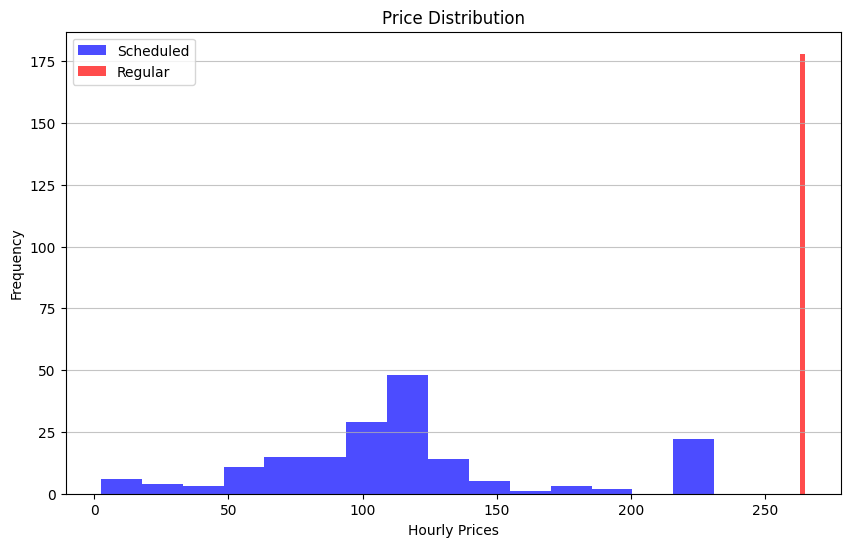

In [42]:
import matplotlib.pyplot as plt

values_index_0 = [value[0] for value in hourly_prices.values()]
values_index_1 = [value[1] for value in hourly_prices.values()]

plt.figure(figsize=(10, 6))

plt.hist(values_index_0, bins=15, alpha=0.7, color='blue', label="Scheduled")
plt.hist(values_index_1, bins=[263, 265], alpha=0.7, color='red', label="Regular")

plt.xlabel("Hourly Prices")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.legend()

plt.grid(axis='y', alpha=0.75)
plt.show()


In [45]:
from scipy.special import softmax

power_rate = 6.6

# Default discrete choice model parameters
dcm_charging_sch_params = np.array(
[[-power_rate * 0.0184 / 2], [power_rate * 0.0184 / 2], [0], [0]]
)
dcm_charging_reg_params = np.array(
[[power_rate * 0.0184 / 2], [-power_rate * 0.0184 / 2], [0], [0.341]]
)
dcm_leaving_params = np.array(
[[power_rate * 0.005 / 2], [power_rate * 0.005 / 2], [0], [-1]]
)
theta = np.vstack((dcm_charging_sch_params.T, dcm_charging_reg_params.T, dcm_leaving_params.T))


zk = [60, 70, 1, 1]
vk = softmax(theta @ zk).flatten()#.reshape(3,1)
vk

array([0.31951277, 0.13340602, 0.54708121])

In [46]:
zk = [1000, 1000, 1, 1]
vk = softmax(theta @ zk).flatten()#.reshape(3,1)
vk

array([1.26641655e-14, 1.78102903e-14, 1.00000000e+00])

In [47]:
theta, zk

(array([[-0.06072,  0.06072,  0.     ,  0.     ],
        [ 0.06072, -0.06072,  0.     ,  0.341  ],
        [ 0.0165 ,  0.0165 ,  0.     , -1.     ]]),
 [1000, 1000, 1, 1])

In [48]:
from scipy.special import softmax

prices = np.arange(20, 50, 5)
tariff_grid = [(z_sch, z_reg) for z_reg in prices for z_sch in prices if z_reg > z_sch]


for z_sch, z_reg in tariff_grid:
    zk = [z_sch, z_reg, 1, 1]
    vk = softmax(theta @ zk).flatten()#.reshape(3,1)
    print(vk[1])

0.32791163405322205
0.22269094988385052
0.31415132893570497
0.1427083362712252
0.21335375763770123
0.29933673196726585
0.08742514318602163
0.13705332524121525
0.2033004127229783
0.28356559284696314
0.05182927009669756
0.08429048256460184
0.13093411304609937
0.19259709054215307
0.2669760671140625
